In [ ]:
import pytorch_lightning as pl
from data import *
from models import *
from analysis import *
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set(style='ticks')

## Set the seeds for reproducibility
pl.seed_everything(2026, workers=True)

Seed set to 2026


2026

In [ ]:
def run_rnn_experiment():
    # Setup Data
    dm = SineWaveDataModule(seq_len=50, batch_size=64, num_samples=2000)
    dm.setup()

    ## PLot a few data samples
    x_sample, y_sample = next(iter(dm.train_dataloader()))
    batch_size, seq_len, in_size = x_sample.shape
    _, out_size = y_sample.shape
    print(f"Data Sample Shape: Input {x_sample.shape}, Target {y_sample.shape}")
    plt.figure(figsize=(10, 4))
    for i in range(5):
        plt.plot(x_sample[i].squeeze().numpy(), label=f'Sample {i+1}')
        # plt.scatter(len(x_sample[i]), y_sample[i].item(), c='r', marker='x') # Target point
    plt.title('Sample Sine Wave Sequences')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

    # Sizes to compare: 1 (Too small), 4 (Likely too small), 32 (Sufficient)
    # hidden_sizes = [2, 32, 48, 52, 64, 128] 
    hidden_sizes = [256]

    results = {}

    for h_size in hidden_sizes:
        print(f"\n--- Training RNN with Hidden Size: {h_size} ---")
        
        # model = RNNRegressor(rnn_type='RNN', 
        #                      input_size=1, 
        #                      hidden_size=h_size, 
        #                      output_size=out_size,
        #                      lr=1e-3)

        model = RNNRegressorSigmoid(rnn_type='RNN', 
                                    input_size=1, 
                                    hidden_size=h_size, 
                                    output_size=out_size,
                                    lr=1e-3)

        # Train
        history = LossHistory()
        checkpoint_callback = pl.callbacks.ModelCheckpoint(
            monitor='val_loss',  # Name of the logged metric
            mode='min',          # Minimize the loss
            save_top_k=1,        # Keep only the best model
            dirpath='checkpoints/', # Directory to save checkpoints (optional)
            filename='best-model-{epoch:02d}-{val_loss:.2f}' # Optional custom filename
        )

        trainer = pl.Trainer(
            max_epochs=500, 
            callbacks=[history, checkpoint_callback], # <--- Add here
            enable_progress_bar=False, 
            logger=False, 
            # enable_checkpointing=False
        )
        trainer.fit(model, dm)

        ## If using a RNNRegressorSigmoid, plot the final sigmoid used:
        if isinstance(model, RNNRegressorSigmoid):
            plot_sigmoid_mask(model.sigparams.detach().cpu().numpy(), h_size, title=f"Learned Sigmoid Mask (Hidden Size {h_size})")

        plot_loss_curves(history, title=f"Training vs Val Loss (Hidden Size {h_size})")

        # Store final val loss
        val_loss = trainer.validate(model, dm, verbose=False)[0]['val_loss']
        results[h_size] = val_loss
        
        # Visualize
        print(f"Final Val Loss: {val_loss:.5f}")
        analyze_hidden_states(model, dm.val_dataloader(), title_suffix=f"(Size {h_size})")

    # Final Loss Comparison
    plt.figure(figsize=(6, 4))
    plt.bar([str(k) for k in results.keys()], results.values(), color='skyblue')
    plt.xlabel('Hidden Size'); plt.ylabel('Validation MSE')
    plt.yscale('log')
    plt.title('Loss vs Hidden Size')
    plt.show()

# if __name__ == "__main__":
#     run_rnn_experiment()

 Current ideas
 - can the target span the basis of the succession of hidden states?
 - to achieve a loss below a certain threshold, the hidden size must be at least X. PAC learning theory?
 - informaiton theory angle; entropy, etc. (the init hidden state is maximum entropy, the RNN must reduce this to a low entropy representation that still allows accurate prediction)
 - duplicate the output, so that the input to the MLP can be smaller than the output... (learning efficient representations)

In [ ]:
def run_autoencoder_experiment():
    # --- 1. Setup Data ---

    dm = SpiralDataModule(
        batch_size=256, 
        num_points=15000, 
        revolutions=10, 
        radius_decay=0.9, 
        noise_level=0.00,
        val_split=0.1
    )
    dm.prepare_data() # Generate data
    dm.setup()

    ## Plot the data in a 3D scatter
    sample_data = dm.train_ds[:][0].numpy()  # Get all training data
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(sample_data[:, 0], sample_data[:, 1], sample_data[:, 2], c='r', s=1, alpha=0.5)
    ax.set_title('3D Spiral Data Sample')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.show();


    # --- 2. Initialize Model ---
    INPUT_DIM = dm.train_ds[0][0].shape[0] # Should be 3
    LATENT_DIM = 64 # The maximum dimension to test (should be >= ambient dim)

    print(f"--- Running Autoencoder Experiment (Input: {INPUT_DIM}, Max Latent: {LATENT_DIM}) ---")
    
    model = AutoencoderSigmoid(
        input_dim=INPUT_DIM, 
        latent_dim=LATENT_DIM, 
        lr=1e-3
    )

    # --- 3. Train Model ---
    history = LossHistory()
    
    trainer = pl.Trainer(
        max_epochs=1, 
        callbacks=[history], 
        enable_progress_bar=False, 
        logger=False,
    )
    trainer.fit(model, dm)

    # --- 4. Plot Loss Curves ---
    plot_loss_curves(history, title=f"Training & Validation Loss (Latent Dim {LATENT_DIM})")
    
    # --- 5. Final Sigmoid Reconstruction ---
    # The learned value of sigparams should be close to 2/LATENT_DIM * LATENT_DIM = 2
    final_sig_param = model.sigparams.detach().cpu().item()
    plot_sigmoid_mask_final(
        final_sig_param, 
        LATENT_DIM, 
        title=f"Learned Latent Mask ($\sigma$={final_sig_param * LATENT_DIM:.2f})"
    )
    
    print(f"\nFinal Learned Sigmoid Cut-off Index: {final_sig_param * LATENT_DIM:.3f}")
    print(f"Final Validation Loss: {history.val_loss[-1]:.6f}")

    # --- 6. PCA Analysis on Latent Codes ---
    analyze_latent_space(model, dm.val_dataloader(), title_suffix=f"(Latent Dim {LATENT_DIM})")

# if __name__ == "__main__":
#     run_autoencoder_experiment()

# Experiments:
 - Next, we can try and reconstruct MNIST: what is the low-dimensional hidden size that allows good reconstruction? (we know this empirically!)
# To-Do:
 - Let's find a force that will want to reduce the drop-off location of the sigmoid mask!#   - e.g., regularization on the sigmoid param to encourage smaller hidden usage

Min and Max of each dimension: [-1.2569746 -1.2589281 -2.9180129] [1.7024024 1.8778739 1.4180576]
Cluster sizes: [473, 1024, 736, 793, 361, 508, 649, 1067, 1051, 838]


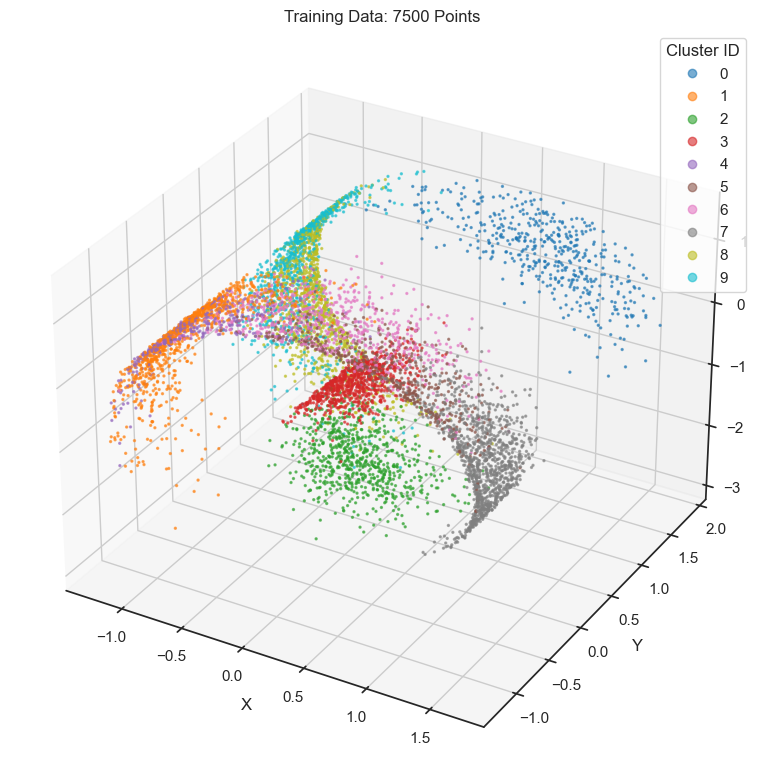

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/ddrous/miniconda3/envs/torchgpu/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/ddrous/Projects/HiddenRep/checkpoints exists and is not empty.

  | Name      | Type       | Params | Mode  | FLOPs
---------------------------------------------------------
0 | encoder   | Sequential | 2.4 K  | train | 0    
1 | decoder   | Sequential | 2.4 K  | train | 0    
2 | criterion | MSELoss    | 0      | train | 0    
---------------------------------------------------------
4.8 K     Trainable params
0         Non-trainable params
4.8 K     Total params
0.019     Total estimated model params size (MB)
13        Modules in train mode
0         Modules

--- Running Autoencoder Experiment (Input: 3, Max Latent: 2) ---


/Users/ddrous/miniconda3/envs/torchgpu/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/ddrous/miniconda3/envs/torchgpu/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=2500` reached.


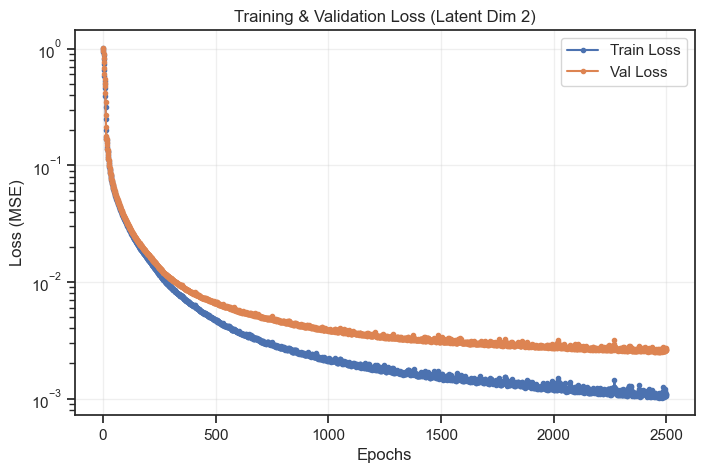

Final Validation Loss: 0.002608


Computing embeddings for 7500 points...


/Users/ddrous/miniconda3/envs/torchgpu/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.



⚡️ Embedding Quality Metrics (Latent Dim 2)
Embedding            | NMI (Struct) | Trustworthiness
------------------------------------------------------------
Autoencoder          | 0.4603       | 0.9992
PCA                  | 0.3713       | 0.9779
t-SNE                | 0.3939       | 0.9998
UMAP                 | 0.5779       | 0.9983



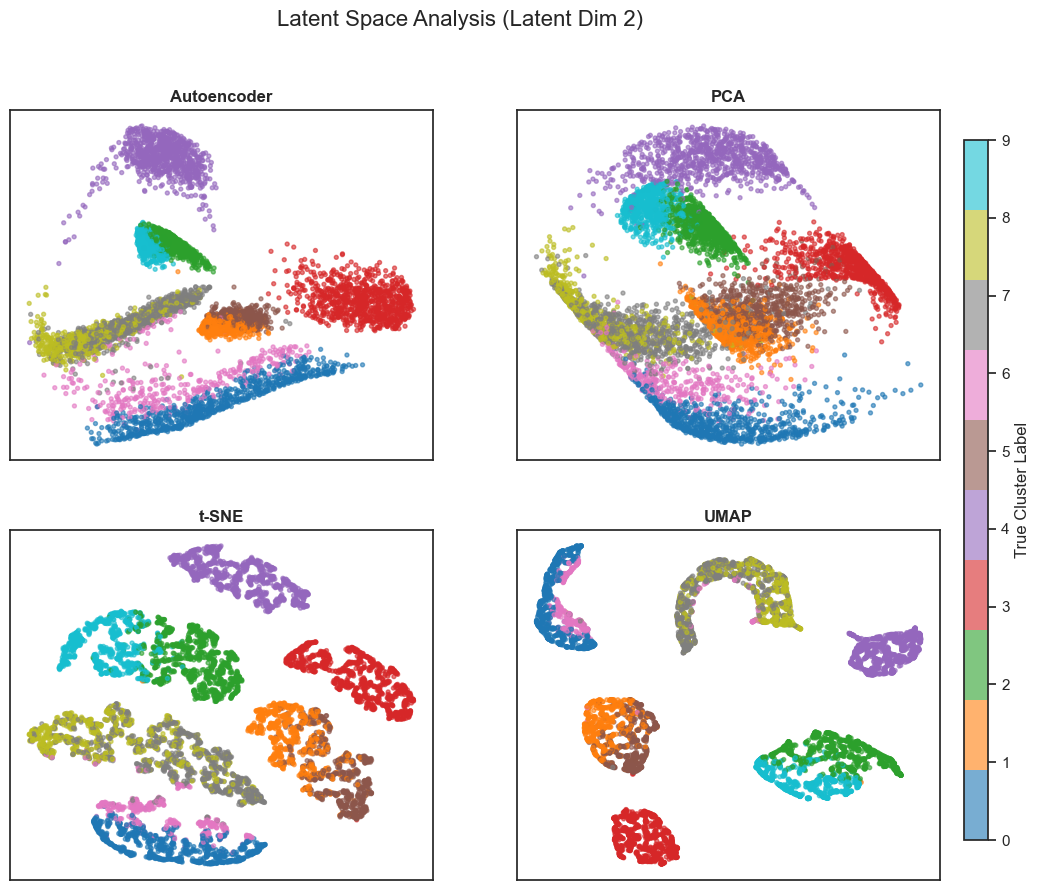

In [ ]:
def run_clustering_experiment():
    # --- 1. Setup Data ---

    dm = SpiralClusteredDataModule(
        batch_size=2048, 
        num_points=15000, 
        noise_level=0.05,
        num_clusters=10,
        cluster_spread=0.4,
        val_split=0.5
    )
    dm.prepare_data() # Generate data
    dm.setup()

    # print(f"Total Train Samples: {dm.train_ds.dataset.labels}")
    # Plot the training points
    # indices = dm.train_ds.indices
    X_train = dm.train_ds.data[:].numpy()
    y_train = dm.train_ds.labels[:].numpy()

    print("Min and Max of each dimension:", np.min(X_train, axis=0), np.max(X_train, axis=0))
    print(f"Cluster sizes: {[np.sum(y_train==i) for i in range(dm.hparams.num_clusters)]}")

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # cmap='tab10' ensures integer labels (0-4) map to distinct colors
    scatter = ax.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], 
                        c=y_train, cmap='tab10', s=2, alpha=0.6)

    ax.legend(*scatter.legend_elements(), title="Cluster ID")
    ax.set_title(f"Training Data: {len(X_train)} Points")
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")

    plt.tight_layout()
    plt.show()


    # --- 2. Initialize Model ---
    INPUT_DIM = dm.train_ds[0][0].shape[0] # Should be 3
    LATENT_DIM = 2 # The maximum dimension to test (should be >= ambient dim)

    print(f"--- Running Autoencoder Experiment (Input: {INPUT_DIM}, Max Latent: {LATENT_DIM}) ---")
    
    model = Autoencoder(
        input_dim=INPUT_DIM, 
        latent_dim=LATENT_DIM, 
        lr=1e-3
    )

    # --- 3. Train Model ---
    history = LossHistory()
    
    trainer = pl.Trainer(
        max_epochs=2500, 
        callbacks=[history], 
        enable_progress_bar=False, 
        check_val_every_n_epoch=1,
        logger=False,
    )
    trainer.fit(model, dm)

    # --- 4. Plot Loss Curves ---
    plot_loss_curves(history, title=f"Training & Validation Loss (Latent Dim {LATENT_DIM})")
    
    print(f"Final Validation Loss: {history.val_loss[-1]:.6f}")

    # --- 5. PCA/t-SNE/UMPA/Plotting of our latent codes ---
    analyze_clustered_embeddings(model=model,
                                ae_latent_dims=(0, 1), 
                            #   dataloader=dm.val_dataloader(), 
                                dataloader=dm.train_dataloader(), 
                                title_suffix=f"(Latent Dim {LATENT_DIM})")

if __name__ == "__main__":
    run_clustering_experiment()

# To-Do:
 - Let's find a force that will want to reduce the drop-off location of the sigmoid mask!#   - e.g., regularization on the sigmoid param to encourage smaller hidden usage